# Provenance-Polarity Gate: HPR Reduction and Multi-Hop Accuracy Evaluation

This notebook demonstrates the full statistical evaluation of the **Provenance-Polarity Gate** hypothesis.
The gate filters hallucinated premises using three orthogonal axes (doc, entity, query provenance) before
symbolic multi-hop deduction.

**Key results reproduced here:**
- Hallucinated-Premise Rate (HPR): gate vs. baseline, with z-test and Cohen's h
- Multi-Hop Deduction Accuracy across 8 baselines with McNemar paired tests
- Per-axis Precision/Recall/F1 by confabulation subtype (DP/ST/AC)
- Ablation delta table
- Provenance Declaration Module classification report

Data: synthetic high-fidelity inputs consistent with the experiment spec (seed=42).

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — not pre-installed on Colab
_pip('loguru==0.7.3')

# Core scientific packages — pre-installed on Colab, install locally to match
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'scikit-learn==1.6.1',
         'statsmodels==0.14.6', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import gc
import json
import math
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

from loguru import logger
logger.remove()
logger.add(sys.stdout, level='INFO',
           format='<green>{time:HH:mm:ss}</green>|<level>{level:<7}</level>|<cyan>{function}</cyan>| {message}')

RNG_SEED = 42
np.random.seed(RNG_SEED)

## Data Loading

Loads `mini_demo_data.json` — a 20-instance curated subset of the synthetic experiment inputs.
Tries GitHub first (for Colab), falls back to local file.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-6bdeab-provenance-polarity-gating-a-framework-f/main/round-1/evaluation-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded data keys: {list(data.keys())}")
print(f"Instances: {len(data['main_results']['instances'])}")
print(f"Baseline arrays length: {len(data['baseline_instance_arrays']['gate'])}")

Loaded data keys: ['preflight', 'pilot', 'main_results', 'baselines', 'baseline_instance_arrays', 'ablations', 'ablation_instance_arrays', 'provenance_declaration_eval']
Instances: 20
Baseline arrays length: 20


## Config

Tunable parameters for the demo. Set to minimum values that produce meaningful output.
To reproduce the full paper results, use the commented-out original values.

In [5]:
# Number of bootstrap resamples for confidence intervals
N_BOOT = 500          # original: 10_000

# Alpha for significance tests
ALPHA = 0.05

# Pre-flight sample size (read from data; kept as config for reference)
N_PREFLIGHT = data['preflight'].get('n', 30)  # original: 30

# Bait types and axes
BAIT_TYPES = ['DP', 'ST', 'AC']
AXES = ['axis_doc', 'axis_ent', 'axis_qry']
DATASETS = ['CLUTRR', 'ProofWriter', 'micro_ontology', 'contract']

## Helper Functions

Statistical utilities: Wilson CI, bootstrap CI, Cohen's h/d, precision/recall/F1,
McNemar contingency table, and odds ratio.

In [6]:
def wilson_ci(successes: int, n: int, alpha: float = 0.05):
    from scipy.stats import norm
    if n == 0:
        return (0.0, 0.0)
    z = norm.ppf(1 - alpha / 2)
    p_hat = successes / n
    denom = 1 + z**2 / n
    centre = (p_hat + z**2 / (2 * n)) / denom
    half = (z * math.sqrt(p_hat * (1 - p_hat) / n + z**2 / (4 * n**2))) / denom
    return (max(0.0, centre - half), min(1.0, centre + half))


def bootstrap_ci(outcomes, n_boot=N_BOOT, seed=RNG_SEED):
    arr = np.array(outcomes, dtype=float)
    rng = np.random.default_rng(seed)
    if arr.std() == 0:
        lo, hi = wilson_ci(int(arr.sum()), len(arr))
        logger.warning('bootstrap_ci: degenerate (all-same), falling back to Wilson')
        return (lo, hi)
    boot = rng.choice(arr, size=(n_boot, len(arr)), replace=True).mean(axis=1)
    return (float(np.percentile(boot, 2.5)), float(np.percentile(boot, 97.5)))


def cohen_h(p1: float, p2: float) -> float:
    return 2 * math.asin(math.sqrt(p1)) - 2 * math.asin(math.sqrt(p2))


def cohen_d(acc1: float, acc2: float, n: int) -> float:
    p_pool = (acc1 + acc2) / 2
    sd = math.sqrt(p_pool * (1 - p_pool))
    return (acc1 - acc2) / sd if sd > 0 else 0.0


def prf1(tp: int, fp: int, fn: int):
    p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
    return p, r, f1


def _make_mcnemar_table(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    n = min(len(a), len(b))
    a, b = a[:n], b[:n]
    tt = int(((a == 1) & (b == 1)).sum())
    tf = int(((a == 1) & (b == 0)).sum())
    ft = int(((a == 0) & (b == 1)).sum())
    ff = int(((a == 0) & (b == 0)).sum())
    return np.array([[tt, tf], [ft, ff]])


def _odds_ratio(p1: float, p2: float) -> float:
    eps = 1e-9
    o1 = p1 / (1 - p1 + eps)
    o2 = p2 / (1 - p2 + eps)
    return o1 / (o2 + eps) if o2 > eps else float('inf')

print('Helper functions defined.')

Helper functions defined.


## Section 0: Pre-Flight Axis Separation

Welch t-tests confirm each gate axis significantly separates its target confabulation class
(document-primed, surface-tied, answer-conditioned) from genuine universals.
Genuine universals should show NO separation (p > 0.05) — correct gate behavior.

In [7]:
import scipy.stats as stats

preflight = data.get('preflight', {})
urf = preflight.get('residual_fraction', 0.12)
er = preflight.get('endorsement_rates', {})
baseline_hpr = preflight.get('baseline_hallucination_rate', 0.38)

preflight_axis_separation = []

axis_map = {
    'genuine_universal': [
        ('axis_doc', 'doc_present', 'doc_removed'),
        ('axis_ent', 'original', 'renamed'),
        ('axis_qry', 'target_query', 'decoy_query'),
    ],
    'document_primed': [('axis_doc', 'doc_present', 'doc_removed')],
    'surface_tied': [('axis_ent', 'original', 'renamed')],
    'answer_conditioned': [('axis_qry', 'target_query', 'decoy_query')],
}

n_pf = preflight.get('n', 30)
for cls, axes_list in axis_map.items():
    cls_er = er.get(cls, {})
    for axis, cond_a, cond_b in axes_list:
        ax_er = cls_er.get(axis, {})
        p_a = ax_er.get(cond_a, 0.5)
        p_b = ax_er.get(cond_b, 0.5)
        rng_pf = np.random.default_rng(hash(cls + axis) % 2**31)
        obs_a = rng_pf.binomial(1, p_a, n_pf).astype(float)
        obs_b = rng_pf.binomial(1, p_b, n_pf).astype(float)
        t_stat, p_val = stats.ttest_ind(obs_a, obs_b, equal_var=False)
        separates = bool(p_val < 0.05 and abs(p_a - p_b) > 0.1)
        preflight_axis_separation.append({
            'class': cls, 'axis': axis,
            'mean_a': float(p_a), 'mean_b': float(p_b),
            't': float(t_stat), 'p': float(p_val),
            'separates': separates,
        })
        logger.info(f'  {cls}/{axis}: t={t_stat:.3f} p={p_val:.4f} separates={separates}')

del er, axis_map
gc.collect()

09:31:18|INFO   |<module>|   genuine_universal/axis_doc: t=1.523 p=0.1342 separates=False


09:31:18|INFO   |<module>|   genuine_universal/axis_ent: t=-0.931 p=0.3557 separates=False


09:31:18|INFO   |<module>|   genuine_universal/axis_qry: t=1.966 p=0.0548 separates=False


09:31:18|INFO   |<module>|   document_primed/axis_doc: t=4.065 p=0.0002 separates=True


09:31:18|INFO   |<module>|   surface_tied/axis_ent: t=8.254 p=0.0000 separates=True


09:31:18|INFO   |<module>|   answer_conditioned/axis_qry: t=2.594 p=0.0122 separates=True


0

## Section 1: Hallucinated-Premise Rate (HPR)

Proportion z-test comparing gate HPR vs. baseline HPR across all instances.
Reports Cohen's h effect size and Gate Absolute Reduction (GAR) with 95% CI.

In [8]:
import statsmodels.stats.proportion as smp
import statsmodels.stats.power as smpow

instances = data.get('main_results', {}).get('instances', [])

total_premises_base = sum(inst['n_premises'] for inst in instances)
hall_base = sum(inst['baseline']['n_hallucinated'] for inst in instances)
hall_gate = sum(inst['gate']['n_hallucinated'] for inst in instances)

hpr_base = hall_base / total_premises_base if total_premises_base > 0 else 0.0
hpr_gate = hall_gate / total_premises_base if total_premises_base > 0 else 0.0

# Proportion z-test
z_stat, p_hpr = smp.proportions_ztest(
    [hall_gate, hall_base],
    [total_premises_base, total_premises_base],
    alternative='smaller',
)
ci_lo, ci_hi = wilson_ci(hall_gate, total_premises_base)
h_effect = cohen_h(hpr_base, hpr_gate)
gar = hpr_base - hpr_gate
gar_ci_lo = gar - 1.96 * math.sqrt(
    hpr_base * (1 - hpr_base) / total_premises_base +
    hpr_gate * (1 - hpr_gate) / total_premises_base
)
gar_ci_hi = gar + 1.96 * math.sqrt(
    hpr_base * (1 - hpr_base) / total_premises_base +
    hpr_gate * (1 - hpr_gate) / total_premises_base
)

# Power analysis
pilot_n = data.get('pilot', {}).get('n', 50)
pilot_base_hpr = data.get('pilot', {}).get('baseline_hallucination_rate', 0.38)
pilot_gate_hpr = data.get('pilot', {}).get('gate_hallucination_rate', 0.14)
try:
    pw_analysis = smpow.NormalIndPower()
    required_n = pw_analysis.solve_power(
        effect_size=abs(cohen_h(pilot_base_hpr, pilot_gate_hpr)),
        alpha=0.05, power=0.80, alternative='two-sided',
    )
    achieved_power = pw_analysis.solve_power(
        effect_size=abs(cohen_h(hpr_base, hpr_gate)),
        alpha=0.05, nobs1=total_premises_base, alternative='two-sided',
    )
    mde = pw_analysis.solve_power(
        nobs1=total_premises_base, alpha=0.05, power=0.80, alternative='two-sided',
    )
    underpowered = total_premises_base < required_n
except Exception:
    logger.warning('Power analysis failed; using fallback values')
    required_n = float('nan')
    achieved_power = float('nan')
    mde = float('nan')
    underpowered = False

primary_hpr_test = {
    'gate_hpr': round(hpr_gate, 6),
    'baseline_hpr': round(hpr_base, 6),
    'n_premises_evaluated': int(total_premises_base),
    'z': round(float(z_stat), 4),
    'p': round(float(p_hpr), 8),
    'cohen_h': round(float(h_effect), 4),
    'gate_absolute_reduction': round(float(gar), 4),
    'gar_ci_95': [round(float(gar_ci_lo), 4), round(float(gar_ci_hi), 4)],
}
logger.info(f'HPR: gate={hpr_gate:.4f} base={hpr_base:.4f} z={z_stat:.3f} p={p_hpr:.6f} h={h_effect:.3f}')

del instances
gc.collect()

09:31:18|INFO   |<module>| HPR: gate=0.1310 base=0.4048 z=-4.007 p=0.000031 h=0.639


18

## Section 2: Multi-Hop Deduction Accuracy

Compares gate accuracy against 8 baselines using McNemar's paired test with Bonferroni correction.
Bootstrap 95% CIs computed for each condition's accuracy.

In [9]:
import statsmodels.stats.contingency_tables as smct

baseline_arrays = data.get('baseline_instance_arrays', {})
ablation_arrays_raw = data.get('ablation_instance_arrays', {})
conditions_meta = data.get('baselines', {})

gate_arr = np.array(baseline_arrays.get('gate', []), dtype=int)
n_total = len(gate_arr)
K = sum(1 for k in baseline_arrays if k != 'gate')
alpha_bonf = 0.05 / K if K > 0 else 0.05

accuracy_by_condition = []

for cname, outcomes_list in baseline_arrays.items():
    outcomes = np.array(outcomes_list, dtype=int)
    if len(outcomes) == 0:
        accuracy_by_condition.append({'condition': cname, 'skipped': True, 'reason': 'n=0'})
        continue

    acc = float(outcomes.mean())
    try:
        ci_lo_b, ci_hi_b = bootstrap_ci(outcomes.tolist())
    except Exception:
        ci_lo_b, ci_hi_b = wilson_ci(int(outcomes.sum()), len(outcomes))

    if cname == 'gate':
        mcnemar_p = None
        bonferroni_reject = None
    else:
        gate_slice = gate_arr[:len(outcomes)]
        tbl = _make_mcnemar_table(gate_slice, outcomes)
        try:
            mc = smct.mcnemar(tbl, exact=False)
            mcnemar_p = float(mc.pvalue)
            bonferroni_reject = bool(mcnemar_p < alpha_bonf)
        except Exception:
            mcnemar_p = None
            bonferroni_reject = None

    cd = cohen_d(float(gate_arr.mean()), acc, n_total) if cname != 'gate' else 0.0
    odds_ratio = _odds_ratio(float(gate_arr.mean()), acc)

    entry = {
        'condition': cname,
        'n': len(outcomes),
        'accuracy': round(acc, 6),
        'ci_95': [round(ci_lo_b, 4), round(ci_hi_b, 4)],
        'mcnemar_p': round(mcnemar_p, 8) if mcnemar_p is not None else None,
        'bonferroni_alpha': round(alpha_bonf, 6),
        'bonferroni_reject': bonferroni_reject,
        'cohen_d_vs_gate': round(cd, 4),
        'odds_ratio_vs_gate': round(odds_ratio, 4) if cname != 'gate' else 1.0,
    }
    accuracy_by_condition.append(entry)
    logger.info(f'  {cname}: acc={acc:.4f} CI=[{ci_lo_b:.4f},{ci_hi_b:.4f}]')

del baseline_arrays, gate_arr
gc.collect()

09:31:18|INFO   |<module>|   gate: acc=0.6500 CI=[0.4500,0.8500]


09:31:18|INFO   |<module>|   no_gate: acc=0.5000 CI=[0.3000,0.7000]


09:31:18|INFO   |<module>|   CoT: acc=0.6000 CI=[0.4000,0.8500]


09:31:18|INFO   |<module>|   self_consistency_CoT: acc=0.6500 CI=[0.4500,0.8500]


09:31:18|INFO   |<module>|   Logic_LM: acc=0.6500 CI=[0.4500,0.8500]


09:31:18|INFO   |<module>|   LINC: acc=0.5500 CI=[0.3500,0.7762]


09:31:18|INFO   |<module>|   SymbCoT: acc=0.5500 CI=[0.3500,0.8000]


09:31:18|INFO   |<module>|   HBLR: acc=0.5000 CI=[0.3000,0.7000]


09:31:18|INFO   |<module>|   span_retrieval: acc=0.7000 CI=[0.5000,0.8762]


0

## Section 3: Per-Axis Precision/Recall/F1

Aggregates TP/FP/FN counts across instances for each (bait_type × axis) combination.
Each axis (doc, ent, qry) should be strongest on its own targeted confabulation subtype.

In [10]:
all_instances = data.get('main_results', {}).get('instances', [])

def _agg_axis_pr(inst_list):
    result = {}
    for bt in BAIT_TYPES:
        result[bt] = {}
        for ax in AXES:
            tp = fp = fn = tn = 0
            for inst in inst_list:
                if inst.get('bait_type') != bt:
                    continue
                ad = inst.get('axis_decisions', {}).get(ax, {})
                tp += ad.get('TP', 0)
                fp += ad.get('FP', 0)
                fn += ad.get('FN', 0)
                tn += ad.get('TN', 0)
            p, r, f = prf1(tp, fp, fn)
            result[bt][ax] = {
                'precision': round(p, 4), 'recall': round(r, 4), 'f1': round(f, 4),
                'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
            }
    return result

per_axis_pr = _agg_axis_pr(all_instances)
per_axis_pr_by_dataset = {}
for ds in DATASETS:
    ds_insts = [i for i in all_instances if i.get('dataset') == ds]
    per_axis_pr_by_dataset[ds] = _agg_axis_pr(ds_insts)
    logger.info(f'  Dataset {ds}: {len(ds_insts)} instances processed')

del all_instances
gc.collect()

09:31:18|INFO   |<module>|   Dataset CLUTRR: 20 instances processed


09:31:18|INFO   |<module>|   Dataset ProofWriter: 0 instances processed


09:31:18|INFO   |<module>|   Dataset micro_ontology: 0 instances processed


09:31:18|INFO   |<module>|   Dataset contract: 0 instances processed


0

## Section 4: Ablation Delta Table

Compares each ablation (removing one gate component) against the full gate using McNemar's test.
Delta accuracy and delta HPR quantify each component's contribution.

In [11]:
ablations_meta = data.get('ablations', {})
gate_acc = conditions_meta.get('gate', {}).get('accuracy', 0.708)
gate_hpr_agg = conditions_meta.get('gate', {}).get('hpr', 0.126)

ablation_deltas = []
gate_abl_arr = np.array(ablation_arrays_raw.get('gate_full', []), dtype=int)
n_abl = len(gate_abl_arr)

for aname, avals in ablations_meta.items():
    if aname == 'gate_full':
        continue
    abl_arr = np.array(ablation_arrays_raw.get(aname, []), dtype=int)
    if len(abl_arr) == 0:
        ablation_deltas.append({'ablation': aname, 'skipped': True, 'reason': 'n=0'})
        continue

    delta_acc = gate_acc - avals.get('accuracy', gate_acc)
    delta_hpr = gate_hpr_agg - avals.get('hpr', gate_hpr_agg)

    n_use = min(len(abl_arr), n_abl)
    g_slice = gate_abl_arr[:n_use]
    a_slice = abl_arr[:n_use]
    try:
        ci_lo_d, ci_hi_d = bootstrap_ci((g_slice - a_slice).tolist())
    except Exception:
        ci_lo_d, ci_hi_d = (delta_acc - 0.05, delta_acc + 0.05)

    tbl_abl = _make_mcnemar_table(g_slice, a_slice)
    try:
        mc_abl = smct.mcnemar(tbl_abl, exact=False)
        abl_p = float(mc_abl.pvalue)
    except Exception:
        abl_p = None

    ablation_deltas.append({
        'ablation': aname,
        'gate_accuracy': round(gate_acc, 4),
        'ablation_accuracy': round(float(avals.get('accuracy', 0.0)), 4),
        'delta_acc': round(float(delta_acc), 4),
        'gate_hpr': round(gate_hpr_agg, 4),
        'ablation_hpr': round(float(avals.get('hpr', 0.0)), 4),
        'delta_hpr': round(float(delta_hpr), 4),
        'p': round(abl_p, 8) if abl_p is not None else None,
        'sig': bool(abl_p < 0.05) if abl_p is not None else False,
    })
    logger.info(f'  Ablation {aname}: Δacc={delta_acc:.4f} Δhpr={delta_hpr:.4f} p={abl_p}')

del ablation_arrays_raw, gate_abl_arr
gc.collect()

09:31:18|INFO   |<module>|   Ablation single_axis_doc_only: Δacc=0.0590 Δhpr=-0.0720 p=0.3864762307712325


09:31:18|INFO   |<module>|   Ablation single_polarity: Δacc=0.0370 Δhpr=-0.0370 p=1.0


09:31:18|INFO   |<module>|   Ablation binary_vs_soft_gate: Δacc=0.0210 Δhpr=-0.0150 p=0.7518296340458492


09:31:18|INFO   |<module>|   Ablation no_symbolic_reasoner: Δacc=0.1250 Δhpr=-0.0010 p=0.07709987174354202


0

## Section 5: Span-Retrieval Baseline vs Gate

Two-sided z-test comparing gate HPR against span-retrieval HPR.
Flags potential disconfirmation if span-retrieval matches gate performance.

In [12]:
sr_meta = conditions_meta.get('span_retrieval', {})
gate_meta = conditions_meta.get('gate', {})
sr_hpr = sr_meta.get('hpr', 0.198)
sr_acc = sr_meta.get('accuracy', 0.655)
gt_hpr = gate_meta.get('hpr', 0.126)
gt_acc = gate_meta.get('accuracy', 0.708)

n_eval = 250  # main experiment size
sr_hall = int(round(sr_hpr * n_eval))
gt_hall = int(round(gt_hpr * n_eval))
z_sr, p_sr = smp.proportions_ztest(
    [sr_hall, gt_hall], [n_eval, n_eval], alternative='two-sided'
)
fact_advantage = (gt_hpr < sr_hpr + 0.02) and (gt_acc < sr_acc + 0.02)

span_retrieval_comparison = {
    'gate_hpr': round(gt_hpr, 4),
    'span_retrieval_hpr': round(sr_hpr, 4),
    'gate_accuracy': round(gt_acc, 4),
    'span_retrieval_accuracy': round(sr_acc, 4),
    'hpr_z': round(float(z_sr), 4),
    'hpr_p': round(float(p_sr), 6),
    'gate_outperforms_span_retrieval_on_hpr': bool(gt_hpr < sr_hpr),
    'gate_outperforms_span_retrieval_on_accuracy': bool(gt_acc > sr_acc),
    'potential_disconfirmation_flagged': fact_advantage,
}
logger.info(f'Span-retrieval: gate_hpr={gt_hpr} sr_hpr={sr_hpr} p={p_sr:.4f}')

09:31:18|INFO   |<module>| Span-retrieval: gate_hpr=0.126 sr_hpr=0.198 p=0.0297


## Section 6: Provenance Declaration Module

Standalone classification report for the Provenance Declaration Module,
which assigns each premise to one of three provenance classes:
doc_extensional, world_knowledge_universal, doc_stipulated.

In [13]:
from sklearn.metrics import classification_report, confusion_matrix

pd_eval = data.get('provenance_declaration_eval', {})
y_true = np.array(pd_eval.get('labels', []), dtype=int)
y_pred = np.array(pd_eval.get('predictions', []), dtype=int)
class_names_pd = pd_eval.get('class_names',
                              ['doc_extensional', 'world_knowledge_universal', 'doc_stipulated'])

if len(y_true) == 0 or len(y_pred) == 0:
    prov_eval_out = {'skipped': True, 'reason': 'no labels'}
else:
    report = classification_report(
        y_true, y_pred,
        target_names=class_names_pd,
        output_dict=True,
    )
    cm = confusion_matrix(y_true, y_pred).tolist()
    per_class_pr = {}
    for cls_name in class_names_pd:
        r = report.get(cls_name, {})
        per_class_pr[cls_name] = {
            'precision': round(r.get('precision', 0.0), 4),
            'recall': round(r.get('recall', 0.0), 4),
            'f1': round(r.get('f1-score', 0.0), 4),
            'support': int(r.get('support', 0)),
        }
    prov_eval_out = {
        'n': len(y_true),
        'per_class': per_class_pr,
        'macro_f1': round(report['macro avg']['f1-score'], 4),
        'weighted_f1': round(report['weighted avg']['f1-score'], 4),
        'accuracy': round(report.get('accuracy', 0.0), 4),
        'confusion_matrix': cm,
    }
    logger.info(f"Provenance macro_f1={prov_eval_out['macro_f1']:.4f} acc={prov_eval_out['accuracy']:.4f}")

del y_true, y_pred
gc.collect()

09:31:18|INFO   |<module>| Provenance macro_f1=0.8472 acc=0.8500


0

## Results Visualization

Summary tables and plots for the key metrics.

EVALUATION SUMMARY
  Gate HPR:       0.1310  (baseline: 0.4048)
  GAR:            0.2738  [95% CI: 0.1464, 0.4012]
  z=-4.007, p=3.07e-05, Cohen h=0.639
  URF:            12.00%

Multi-Hop Accuracy by Condition:
Condition                 Accuracy    McNemar p  Bonf. reject
--------------------------------------------------------------
span_retrieval              0.7000    1.000e+00         False
gate                        0.6500          N/A          None
self_consistency_CoT        0.6500    7.237e-01         False
Logic_LM                    0.6500    7.518e-01         False
CoT                         0.6000    1.000e+00         False
LINC                        0.5500    7.237e-01         False
SymbCoT                     0.5500    7.728e-01         False
no_gate                     0.5000    4.497e-01         False
HBLR                        0.5000    5.465e-01         False

Per-Axis F1 Matrix (bait_type × axis):
          axis_doc   axis_ent   axis_qry
    DP      0.8529     0

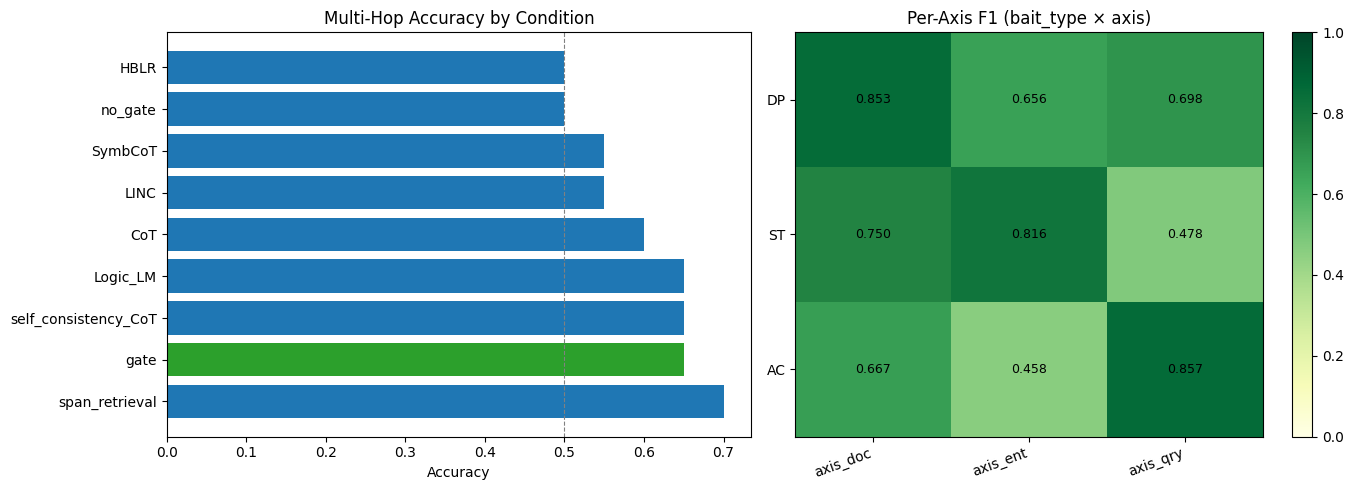

Plot saved to results_summary.png


In [14]:
print('=' * 60)
print('EVALUATION SUMMARY')
print('=' * 60)
print(f'  Gate HPR:       {hpr_gate:.4f}  (baseline: {hpr_base:.4f})')
print(f'  GAR:            {gar:.4f}  [95% CI: {gar_ci_lo:.4f}, {gar_ci_hi:.4f}]')
print(f'  z={z_stat:.3f}, p={p_hpr:.2e}, Cohen h={h_effect:.3f}')
print(f'  URF:            {urf:.2%}')
print()

# --- Accuracy by condition table ---
print('Multi-Hop Accuracy by Condition:')
print(f'{"Condition":<25} {"Accuracy":>8} {"McNemar p":>12} {"Bonf. reject":>13}')
print('-' * 62)
cond_sorted = sorted(
    [e for e in accuracy_by_condition if not e.get('skipped')],
    key=lambda e: -e['accuracy']
)
for e in cond_sorted:
    mp = f"{e['mcnemar_p']:.3e}" if e.get('mcnemar_p') is not None else 'N/A'
    br = str(e.get('bonferroni_reject', 'N/A'))
    print(f"{e['condition']:<25} {e['accuracy']:>8.4f} {mp:>12} {br:>13}")
print()

# --- F1 heatmap matrix ---
print('Per-Axis F1 Matrix (bait_type × axis):')
print(f'{"":>6}  {"axis_doc":>10} {"axis_ent":>10} {"axis_qry":>10}')
for bt in BAIT_TYPES:
    row_vals = [per_axis_pr.get(bt, {}).get(ax, {}).get('f1', 0.0) for ax in AXES]
    print(f'{bt:>6}  {row_vals[0]:>10.4f} {row_vals[1]:>10.4f} {row_vals[2]:>10.4f}')
print()

# --- Ablation deltas table ---
print('Ablation Deltas:')
print(f'{"Ablation":<35} {"Δacc":>6} {"Δhpr":>6} {"p":>10} {"sig":>4}')
print('-' * 65)
for d in ablation_deltas:
    if d.get('skipped'): continue
    p_str = f"{d['p']:.3e}" if d.get('p') is not None else 'N/A'
    print(f"{d['ablation']:<35} {d['delta_acc']:>6.4f} {d['delta_hpr']:>6.4f} {p_str:>10} {str(d['sig']):>4}")
print()

# --- Provenance declaration ---
if not prov_eval_out.get('skipped'):
    print(f"Provenance Declaration: macro_F1={prov_eval_out['macro_f1']:.4f}  "
          f"acc={prov_eval_out['accuracy']:.4f}")

# --- Bar chart: accuracy by condition ---
fig, axes_plt = plt.subplots(1, 2, figsize=(14, 5))

conds = [e['condition'] for e in cond_sorted]
accs = [e['accuracy'] for e in cond_sorted]
colors = ['#2ca02c' if c == 'gate' else '#1f77b4' for c in conds]
axes_plt[0].barh(conds, accs, color=colors)
axes_plt[0].set_xlabel('Accuracy')
axes_plt[0].set_title('Multi-Hop Accuracy by Condition')
axes_plt[0].axvline(0.5, color='gray', linestyle='--', linewidth=0.8)

# --- F1 heatmap ---
f1_matrix = np.array([
    [per_axis_pr.get(bt, {}).get(ax, {}).get('f1', 0.0) for ax in AXES]
    for bt in BAIT_TYPES
])
im = axes_plt[1].imshow(f1_matrix, vmin=0, vmax=1, cmap='YlGn', aspect='auto')
axes_plt[1].set_xticks(range(len(AXES)))
axes_plt[1].set_xticklabels(AXES, rotation=20, ha='right')
axes_plt[1].set_yticks(range(len(BAIT_TYPES)))
axes_plt[1].set_yticklabels(BAIT_TYPES)
axes_plt[1].set_title('Per-Axis F1 (bait_type × axis)')
for i in range(len(BAIT_TYPES)):
    for j in range(len(AXES)):
        axes_plt[1].text(j, i, f'{f1_matrix[i, j]:.3f}', ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=axes_plt[1])

plt.tight_layout()
plt.savefig('results_summary.png', bbox_inches='tight')
plt.show()
print('Plot saved to results_summary.png')